### Network Construction

In [6]:
import pandas as pd
import numpy as np
import networkx as nx
import requests
import os

data_processed = os.path.expanduser("~/Pan-Autoimmune-miRNA-ML/data/processed")

print("Libraries loaded")

Libraries loaded


In [7]:
## Load miRTarBase human miRNA-mRNA interaction database
## Source: miRTarBase v10.0 — experimentally validated interactions only

mirtarbase = pd.read_csv(
    os.path.expanduser("~/Pan-Autoimmune-miRNA-ML/data/raw/hsa_MTI.csv"),
    low_memory=False
)

print(mirtarbase.shape)
print(mirtarbase.columns.tolist())
print(mirtarbase.head(3))

(4004967, 9)
['miRTarBase ID', 'miRNA', 'Species (miRNA)', 'Target Gene', 'Target Gene (Entrez ID)', 'Species (Target Gene)', 'Experiments', 'Support Type', 'References (PMID)']
  miRTarBase ID           miRNA Species (miRNA) Target Gene  \
0    MIRT003105  hsa-miR-122-5p             hsa      SLC7A1   
1    MIRT003105  hsa-miR-122-5p             hsa      SLC7A1   
2    MIRT003105  hsa-miR-122-5p             hsa      SLC7A1   

   Target Gene (Entrez ID) Species (Target Gene)  \
0                   6541.0                   hsa   
1                   6541.0                   hsa   
2                   6541.0                   hsa   

                               Experiments        Support Type  \
0  Luciferase reporter assay//Western blot      Functional MTI   
1  Luciferase reporter assay//Western blot  Non-Functional MTI   
2  Luciferase reporter assay//Western blot  Non-Functional MTI   

   References (PMID)  
0         17179747.0  
1         17179747.0  
2         17179747.0  


In [8]:
## Keep only Functional MTI and extract relevant columns
## Non-Functional MTIs are experimentally tested but show no regulatory effect

mirtarbase_clean = mirtarbase[mirtarbase['Support Type'] == 'Functional MTI'][['miRNA', 'Target Gene']].drop_duplicates()

print(f"Total interactions after filtering: {mirtarbase_clean.shape[0]}")
print(mirtarbase_clean.head())

Total interactions after filtering: 8905
             miRNA Target Gene
0   hsa-miR-122-5p      SLC7A1
5   hsa-miR-122-5p      ADAM17
14  hsa-miR-122-5p       NUMBL
15  hsa-miR-122-5p       FOXJ3
16  hsa-miR-122-5p        XPO6


In [10]:
## Load DEG results and match against miRTarBase interactions
## This identifies miRNAs that regulate our disease-relevant genes

deg_genes = {}
for disease in ["Vitiligo", "SLE", "RA", "T1D"]:
    sig = pd.read_csv(f"{data_processed}/{disease}_DEGs.csv", index_col=0)
    deg_genes[disease] = set(sig.index.tolist())
    print(f"{disease}: {len(deg_genes[disease])} DEGs")

# Find miRNA-mRNA interactions for DEG genes across all diseases
all_deg_genes = set().union(*deg_genes.values())
print(f"\nTotal unique DEGs across all diseases: {len(all_deg_genes)}")

# Filter miRTarBase for our DEGs
network_interactions = mirtarbase_clean[
    mirtarbase_clean['Target Gene'].isin(all_deg_genes)
]
print(f"miRNA-mRNA interactions involving DEGs: {len(network_interactions)}")

Vitiligo: 2745 DEGs
SLE: 3265 DEGs
RA: 9127 DEGs
T1D: 0 DEGs

Total unique DEGs across all diseases: 11964
miRNA-mRNA interactions involving DEGs: 5464


In [12]:
## Build miRNA-mRNA network using NetworkX
## Nodes = miRNAs and genes, Edges = regulatory interactions

G = nx.DiGraph()  # Directed graph — miRNA → mRNA direction

for _, row in network_interactions.iterrows():
    mirna = row['miRNA']
    gene = row['Target Gene']
    G.add_edge(mirna, gene)

print(f"Network nodes: {G.number_of_nodes()}")
print(f"Network edges: {G.number_of_edges()}")
print(f"miRNA nodes: {sum(1 for n in G.nodes() if n.startswith('hsa-miR') or n.startswith('hsa-let'))}")
print(f"Gene nodes: {sum(1 for n in G.nodes() if not (n.startswith('hsa-miR') or n.startswith('hsa-let')))}")

Network nodes: 2698
Network edges: 5464
miRNA nodes: 814
Gene nodes: 1884


In [13]:
## Identify hub miRNAs by out-degree (number of genes each miRNA regulates)

mirna_degree = {n: G.out_degree(n) for n in G.nodes() 
                if n.startswith('hsa-miR') or n.startswith('hsa-let')}

degree_df = pd.DataFrame.from_dict(mirna_degree, orient='index', columns=['degree'])
degree_df = degree_df.sort_values('degree', ascending=False)

print("Top 20 hub miRNAs:")
print(degree_df.head(20))

Top 20 hub miRNAs:
                 degree
hsa-miR-124-3p       69
hsa-miR-125b-5p      67
hsa-miR-155-5p       67
hsa-miR-34a-5p       64
hsa-miR-29a-3p       62
hsa-miR-29b-3p       61
hsa-miR-21-5p        61
hsa-miR-145-5p       58
hsa-miR-26a-5p       54
hsa-miR-27a-3p       53
hsa-miR-24-3p        51
hsa-miR-17-5p        51
hsa-miR-221-3p       49
hsa-miR-122-5p       47
hsa-miR-1-3p         46
hsa-miR-200c-3p      44
hsa-miR-146a-5p      42
hsa-miR-16-5p        42
hsa-miR-199a-5p      41
hsa-miR-181a-5p      40


In [14]:
## Find miRNAs shared across multiple diseases — pan-autoimmune regulators

disease_mirnas = {}
for disease in ["Vitiligo", "SLE", "RA"]:
    genes = deg_genes[disease]
    mirnas = set(
        network_interactions[network_interactions['Target Gene'].isin(genes)]['miRNA']
    )
    disease_mirnas[disease] = mirnas
    print(f"{disease}: {len(mirnas)} miRNAs")

# Find shared miRNAs
shared_all = disease_mirnas["Vitiligo"] & disease_mirnas["SLE"] & disease_mirnas["RA"]
print(f"\nmiRNAs shared across Vitiligo, SLE and RA: {len(shared_all)}")
print(sorted(shared_all)[:20])

Vitiligo: 403 miRNAs
SLE: 505 miRNAs
RA: 798 miRNAs

miRNAs shared across Vitiligo, SLE and RA: 289
['ebv-miR-BART6-5p', 'hsa-let-7a-5p', 'hsa-let-7b-3p', 'hsa-let-7b-5p', 'hsa-let-7c-5p', 'hsa-let-7d-5p', 'hsa-let-7e-5p', 'hsa-let-7f-5p', 'hsa-let-7g-5p', 'hsa-let-7i-5p', 'hsa-miR-1-3p', 'hsa-miR-100-5p', 'hsa-miR-101-3p', 'hsa-miR-101-5p', 'hsa-miR-103a-3p', 'hsa-miR-105-5p', 'hsa-miR-106a-3p', 'hsa-miR-106a-5p', 'hsa-miR-106b-5p', 'hsa-miR-107']


In [15]:
## Save network interactions and shared pan-autoimmune miRNAs

# Save full network interactions
network_interactions.to_csv(f"{data_processed}/pan_autoimmune_network_interactions.csv", index=False)

# Save shared miRNAs
shared_df = pd.DataFrame(sorted(shared_all), columns=['miRNA'])
shared_df.to_csv(f"{data_processed}/shared_pan_autoimmune_miRNAs.csv", index=False)

# Save hub miRNA rankings
degree_df.to_csv(f"{data_processed}/hub_miRNAs_ranked.csv")

print(f"Saved network interactions: {len(network_interactions)} edges")
print(f"Saved shared miRNAs: {len(shared_all)}")
print(f"Saved hub miRNA rankings: {len(degree_df)}")

Saved network interactions: 5464 edges
Saved shared miRNAs: 289
Saved hub miRNA rankings: 814


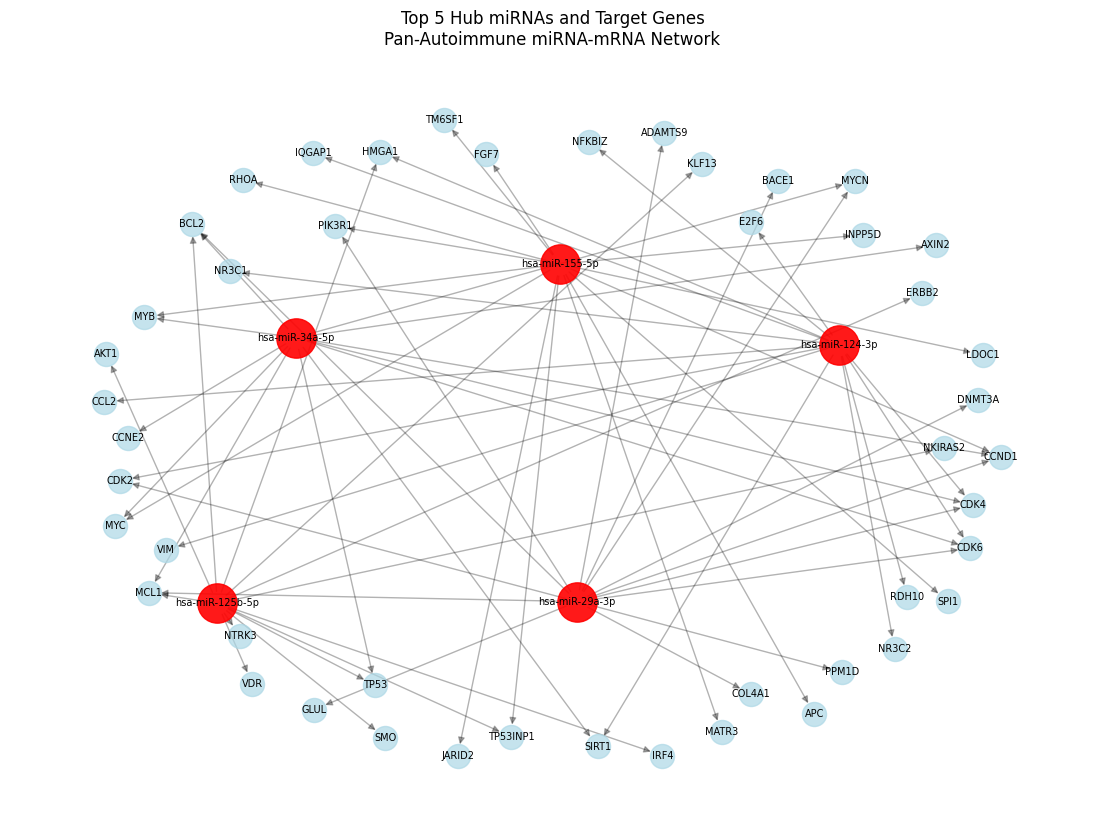

Network visualization saved


In [16]:
import matplotlib.pyplot as plt
import networkx as nx

## Visualize top hub miRNAs and their target genes
## Showing top 5 hub miRNAs and their connections

top_mirnas = degree_df.head(5).index.tolist()
subgraph_nodes = set(top_mirnas)
for mirna in top_mirnas:
    targets = list(G.successors(mirna))[:10]
    subgraph_nodes.update(targets)

H = G.subgraph(subgraph_nodes)

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(H, seed=42, k=2)

mirna_nodes = [n for n in H.nodes() if n.startswith('hsa')]
gene_nodes = [n for n in H.nodes() if not n.startswith('hsa')]

nx.draw_networkx_nodes(H, pos, nodelist=mirna_nodes, node_color='red', node_size=800, alpha=0.9)
nx.draw_networkx_nodes(H, pos, nodelist=gene_nodes, node_color='lightblue', node_size=300, alpha=0.7)
nx.draw_networkx_edges(H, pos, alpha=0.3, arrows=True)
nx.draw_networkx_labels(H, pos, font_size=7)

plt.title("Top 5 Hub miRNAs and Target Genes\nPan-Autoimmune miRNA-mRNA Network", fontsize=12)
plt.axis('off')

figures_path = os.path.expanduser("~/Pan-Autoimmune-miRNA-ML/results/figures")
plt.savefig(f"{figures_path}/miRNA_network_hub.png", dpi=300, bbox_inches='tight')
plt.show()
print("Network visualization saved")